In [1]:
# Cell 1 — Setup
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

try:
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
except Exception:
    raise ImportError("nltk not found in this kernel. Run: %pip install nltk")

# Resolve project root
candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/Users/dannyyy/Downloads/accessops_coco_ai"),
]
PROJECT_ROOT = None
for c in candidates:
    if (c / "artifacts").exists() and (c / "notebooks").exists():
        PROJECT_ROOT = c
        break
assert PROJECT_ROOT is not None, "Could not resolve PROJECT_ROOT."

ART = PROJECT_ROOT / "artifacts"
OUT = ART / "final" / "error_analysis"
OUT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT:", OUT)


PROJECT_ROOT: /Users/dannyyy/Downloads/accessops_coco_ai
OUT: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/final/error_analysis


In [2]:
# Cell 2 — Load data + compute BLEU for RAG captions
stage6_pred = ART / "stage6" / "reroute_predictions.csv"
stage7_pred = ART / "stage7" / "rag_predictions.csv"
caps_csv = ART / "captions_clean_with_splits.csv"
policy_json = ART / "final" / "deployment_policy.json"

assert stage6_pred.exists(), f"Missing: {stage6_pred}"
assert stage7_pred.exists(), f"Missing: {stage7_pred}"
assert caps_csv.exists(), f"Missing: {caps_csv}"

base_df = pd.read_csv(stage6_pred)   # image_name, caption, confidence, bleu4
rag_df = pd.read_csv(stage7_pred)    # image_name, base_caption, rag_caption, retrieval fields
caps_df = pd.read_csv(caps_csv)

# Normalize key cols
for d in (base_df, rag_df, caps_df):
    d["image_name"] = d["image_name"].astype(str).str.strip()

base_df = base_df.rename(columns={"caption": "base_caption", "bleu4": "base_bleu4"})
base_df["base_bleu4"] = pd.to_numeric(base_df["base_bleu4"], errors="coerce")
base_df["confidence"] = pd.to_numeric(base_df["confidence"], errors="coerce")

# References map (test split, all available references)
test_refs = caps_df[caps_df["split"].astype(str).str.lower() == "test"].copy()
test_refs["comment_clean"] = test_refs["comment_clean"].astype(str).str.strip().str.lower()
refs_by_image = test_refs.groupby("image_name")["comment_clean"].apply(list).to_dict()

# Merge base + rag
keep_rag_cols = [
    "image_name", "base_caption", "rag_caption",
    "retrieved_caption_top1", "retrieval_sim_top1", "rag_used_retrieval"
]
df = base_df.merge(rag_df[keep_rag_cols], on="image_name", how="left", suffixes=("", "_ragsrc"))

# Use base caption from stage6 as source of truth
df["base_caption"] = df["base_caption"].astype(str).str.strip().str.lower()
df["rag_caption"] = df["rag_caption"].fillna(df["base_caption"]).astype(str).str.strip().str.lower()
df["retrieval_sim_top1"] = pd.to_numeric(df["retrieval_sim_top1"], errors="coerce")
df["rag_used_retrieval"] = pd.to_numeric(df["rag_used_retrieval"], errors="coerce").fillna(0).astype(int)

# Policy threshold
threshold = 0.5
if policy_json.exists():
    threshold = float(json.loads(policy_json.read_text(encoding="utf-8")).get("selected_threshold", 0.5))

df["route_policy"] = np.where(df["confidence"] >= threshold, "AUTO", "HUMAN_REVIEW")

# Compute RAG BLEU4 against test references
sf = SmoothingFunction().method1

def bleu4_one(caption: str, refs: list[str]) -> float:
    if not isinstance(caption, str):
        return np.nan
    toks = caption.strip().split()
    ref_toks = [r.split() for r in refs if isinstance(r, str) and r.strip()]
    if not toks or not ref_toks:
        return np.nan
    return float(sentence_bleu(ref_toks, toks, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=sf))

df["rag_bleu4"] = [
    bleu4_one(cap, refs_by_image.get(img, []))
    for img, cap in zip(df["image_name"], df["rag_caption"])
]

df["rag_delta_bleu4"] = df["rag_bleu4"] - df["base_bleu4"]
df["ref_1"] = df["image_name"].map(lambda x: refs_by_image.get(x, [""])[0] if refs_by_image.get(x) else "")

print("Rows:", len(df), "| Threshold:", round(threshold, 4))
display(df.head(3))


Rows: 2500 | Threshold: 0.5115


,image_name,base_caption,confidence,base_bleu4,base_caption_ragsrc,rag_caption,retrieved_caption_top1,retrieval_sim_top1,rag_used_retrieval,route_policy,rag_bleu4,rag_delta_bleu4,ref_1
0,000000289594.jpg,a man is walking down the street with a cell p...,0.497802,0.131938,a man is walking down the street with a cell p...,a man is walking down the street with a cell p...,a woman walking down the street with a cell phone,0.820652,0,HUMAN_REVIEW,0.131938,8.326673e-17,a man in a hat leaning against a pole
1,000000289659.jpg,a giraffe standing next to a tree in a field,0.540593,0.137471,a giraffe standing next to a tree in a field,a giraffe standing next to a tree in a field,a tall giraffe standing next to a tree in a field,0.877801,0,AUTO,0.137471,2.775558e-17,a giraffe standing on top of a dirt and grass ...
2,000000289702.jpg,a dog is sitting on a table with a bottle of wine,0.395040,0.252119,a dog is sitting on a table with a bottle of wine,a dog sitting on a couch with a bottle of wine,a dog sitting on a couch with a bottle of wine,0.657808,1,HUMAN_REVIEW,0.064841,-1.872782e-01,large black dog sitting in front of a big mirror


In [3]:
# Cell 3 — Core summaries
overall = pd.DataFrame([{
    "n_images": int(len(df)),
    "policy_threshold": float(threshold),
    "base_bleu4_mean": float(df["base_bleu4"].mean()),
    "rag_bleu4_mean": float(df["rag_bleu4"].mean()),
    "delta_bleu4_mean": float(df["rag_delta_bleu4"].mean()),
    "rag_used_rate": float(df["rag_used_retrieval"].mean()),
    "improved_rate_(rag>base)": float((df["rag_delta_bleu4"] > 0).mean()),
    "degraded_rate_(rag<base)": float((df["rag_delta_bleu4"] < 0).mean()),
}])

route_summary = (
    df.groupby("route_policy", as_index=False)
      .agg(
          n=("image_name", "count"),
          mean_confidence=("confidence", "mean"),
          base_bleu4_mean=("base_bleu4", "mean"),
          rag_bleu4_mean=("rag_bleu4", "mean"),
          delta_bleu4_mean=("rag_delta_bleu4", "mean"),
      )
      .sort_values("route_policy")
)

rag_usage_summary = (
    df.groupby("rag_used_retrieval", as_index=False)
      .agg(
          n=("image_name", "count"),
          mean_confidence=("confidence", "mean"),
          base_bleu4_mean=("base_bleu4", "mean"),
          rag_bleu4_mean=("rag_bleu4", "mean"),
          delta_bleu4_mean=("rag_delta_bleu4", "mean"),
      )
      .sort_values("rag_used_retrieval")
)

display(overall)
display(route_summary)
display(rag_usage_summary)


,n_images,policy_threshold,base_bleu4_mean,rag_bleu4_mean,delta_bleu4_mean,rag_used_rate,improved_rate_(rag>base),degraded_rate_(rag<base)
0,2500,0.511473,0.222123,0.221124,-0.000999,0.0832,0.6276,0.0392


,route_policy,n,mean_confidence,base_bleu4_mean,rag_bleu4_mean,delta_bleu4_mean
0,AUTO,1250,0.594665,0.281354,0.281354,3.035905e-17
1,HUMAN_REVIEW,1250,0.440082,0.162891,0.160894,-1.997532e-03


,rag_used_retrieval,n,mean_confidence,base_bleu4_mean,rag_bleu4_mean,delta_bleu4_mean
0,0,2292,0.531249,0.231329,0.231329,3.283108e-17
1,1,208,0.364472,0.120674,0.108669,-1.200440e-02


In [4]:
# Cell 4 — Best/worst examples tables
cols = [
    "image_name", "confidence", "route_policy",
    "base_bleu4", "rag_bleu4", "rag_delta_bleu4",
    "base_caption", "rag_caption", "ref_1",
    "rag_used_retrieval", "retrieval_sim_top1"
]

top20_best = df.sort_values("base_bleu4", ascending=False).head(20)[cols]
top20_worst = df.sort_values("base_bleu4", ascending=True).head(20)[cols]

top20_rag_improved = df.sort_values("rag_delta_bleu4", ascending=False).head(20)[cols]
top20_rag_degraded = df.sort_values("rag_delta_bleu4", ascending=True).head(20)[cols]

display(top20_best.head(5))
display(top20_worst.head(5))
display(top20_rag_improved.head(5))
display(top20_rag_degraded.head(5))


,image_name,confidence,route_policy,base_bleu4,rag_bleu4,rag_delta_bleu4,base_caption,rag_caption,ref_1,rag_used_retrieval,retrieval_sim_top1
1256,000000436617.jpg,0.654219,AUTO,1.0,1.0,0.0,a group of people sitting around a table,a group of people sitting around a table,there is a group of people sitting at a table,0,1.0
1767,000000492968.jpg,0.735874,AUTO,1.0,1.0,0.0,a man riding a snowboard down a snow covered s...,a man riding a snowboard down a snow covered s...,a snowboarder with black and white clothes fin...,0,1.0
438,000000341196.jpg,0.731610,AUTO,1.0,1.0,0.0,a man riding a wave on top of a surfboard,a man riding a wave on top of a surfboard,a man riding a wave on top of a surfboard,0,1.0
37,000000292908.jpg,0.679714,AUTO,1.0,1.0,0.0,a person riding a surf board on a wave,a person riding a surf board on a wave,a man is surfing on a wave in the ocean,0,1.0
1442,000000457559.jpg,0.710818,AUTO,1.0,1.0,0.0,a group of young men playing a game of soccer,a group of young men playing a game of soccer,a group of young men playing a game of soccer,0,1.0


,image_name,confidence,route_policy,base_bleu4,rag_bleu4,rag_delta_bleu4,base_caption,rag_caption,ref_1,rag_used_retrieval,retrieval_sim_top1
877,000000390301.jpg,0.520152,AUTO,0.021105,0.021105,4.510281e-17,a woman walking down a street holding a red um...,a woman walking down a street holding a red um...,a white and green rusted fire hydrant spewing ...,0,0.722915
1008,000000406417.jpg,0.487586,HUMAN_REVIEW,0.022417,0.022417,3.469447e-18,a group of people standing on a field with a kite,a group of people standing on a field with a kite,three little kids that have different ties on,0,0.836896
1927,000000512929.jpg,0.540368,AUTO,0.024089,0.024089,1.387779e-17,a woman is sitting at a table with a plate of ...,a woman is sitting at a table with a plate of ...,a pair of girls are cooking in one pan together,0,0.885478
977,000000402783.jpg,0.446677,HUMAN_REVIEW,0.024089,0.024089,1.387779e-17,a plate of food with a sandwich and a cup of c...,a plate of food with a sandwich and a cup of c...,a white plate topped with orange peel slices,0,0.751127
1548,000000467776.jpg,0.680916,AUTO,0.024089,0.024089,1.387779e-17,a couple of horses standing on top of a lush g...,a couple of horses standing on top of a lush g...,a mother and its calf standing in a field,0,1.000000


,image_name,confidence,route_policy,base_bleu4,rag_bleu4,rag_delta_bleu4,base_caption,rag_caption,ref_1,rag_used_retrieval,retrieval_sim_top1
2365,000000565989.jpg,0.382279,HUMAN_REVIEW,0.144989,0.467138,0.322149,a clock on a building with a clock on the front,a large building with a clock on the front,large clock sitting on the side of a large bui...,1,0.791443
2418,000000571943.jpg,0.297796,HUMAN_REVIEW,0.071597,0.324668,0.253071,a street sign with a clock on it,the side of a builing with a clock on it,a pole with a street light and signs next to a...,1,0.604973
1826,000000500565.jpg,0.345177,HUMAN_REVIEW,0.281100,0.505423,0.224323,a woman holding a baby in her arms and a man i...,a woman is holding a baby in her arms,a woman holding a child wrapped in a towel bru...,1,0.684789
655,000000365098.jpg,0.385552,HUMAN_REVIEW,0.392815,0.596949,0.204135,a boat is docked on the water near a dock,a boat is on the water near a dock,an empty boat in the water near a tree,1,0.770497
184,000000309964.jpg,0.337067,HUMAN_REVIEW,0.152136,0.330316,0.178180,a woman and a man are standing under a umbrella,a woman and man are standing near a table,the people are sitting outside under a large u...,1,0.603015


,image_name,confidence,route_policy,base_bleu4,rag_bleu4,rag_delta_bleu4,base_caption,rag_caption,ref_1,rag_used_retrieval,retrieval_sim_top1
1706,000000485802.jpg,0.317997,HUMAN_REVIEW,0.496168,0.163481,-0.332687,a large airplane flying in the sky with a blue...,a large airplane flying in the blue sky,an airplane leaving a trail in the sky,1,0.775529
346,000000329319.jpg,0.388036,HUMAN_REVIEW,0.587395,0.312394,-0.275001,a cat sitting on a chair in a garden,a cat is sitting on a chair in a garden,a black and white cat sitting on top of a wood...,1,0.857447
1283,000000439715.jpg,0.398310,HUMAN_REVIEW,0.441248,0.174439,-0.266809,a man riding a horse in a field,a man is riding a horse in a field,a man riding a brown horse in uniform next to ...,1,0.798343
1588,000000473015.jpg,0.398429,HUMAN_REVIEW,0.427287,0.180922,-0.246365,a person is windsurfing in the water near a li...,a person that is windsurfing in the water,a duck swims in some water near some vegetation,1,0.681597
362,000000331352.jpg,0.335680,HUMAN_REVIEW,0.368894,0.124219,-0.244675,a toilet with a toilet seat and a sink,a toilet with out a toilet seat and a shelf,a small closed toilet in a cramped space,1,0.622055


In [5]:
# Cell 5 — Failure bucketing (rule-based)
df["base_len"] = df["base_caption"].fillna("").str.split().str.len().fillna(0).astype(int)

def bucket(row):
    b = row["base_bleu4"]
    d = row["rag_delta_bleu4"]
    c = row["confidence"]
    l = row["base_len"]

    if pd.isna(b):
        return "missing_metric"
    if b < 0.05 and c >= threshold:
        return "high_confidence_low_quality"
    if d > 0.05:
        return "rag_helped_strongly"
    if d < -0.05:
        return "rag_hurt_strongly"
    if l <= 6:
        return "short_generic_caption"
    if b >= 0.30:
        return "strong_caption"
    return "medium_or_ambiguous"

df["error_bucket"] = df.apply(bucket, axis=1)

bucket_counts = (
    df["error_bucket"]
      .value_counts(dropna=False)
      .rename_axis("error_bucket")
      .reset_index(name="count")
)

display(bucket_counts)


,error_bucket,count
0,medium_or_ambiguous,1676
1,strong_caption,701
2,high_confidence_low_quality,81
3,rag_hurt_strongly,30
4,rag_helped_strongly,12


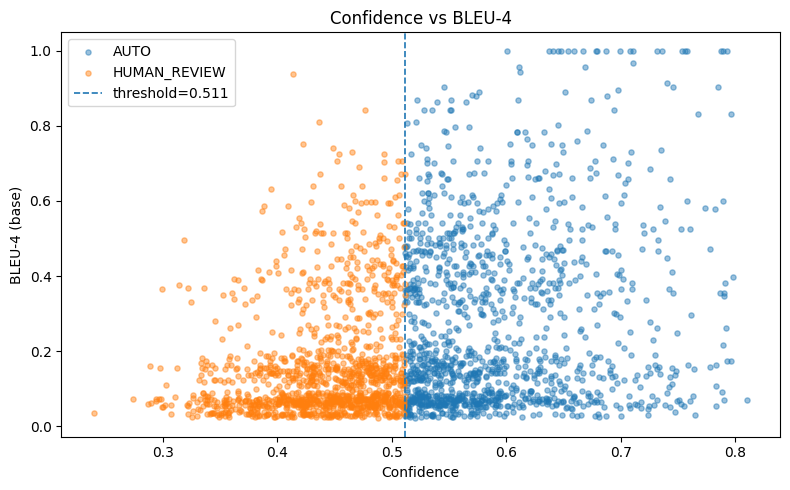

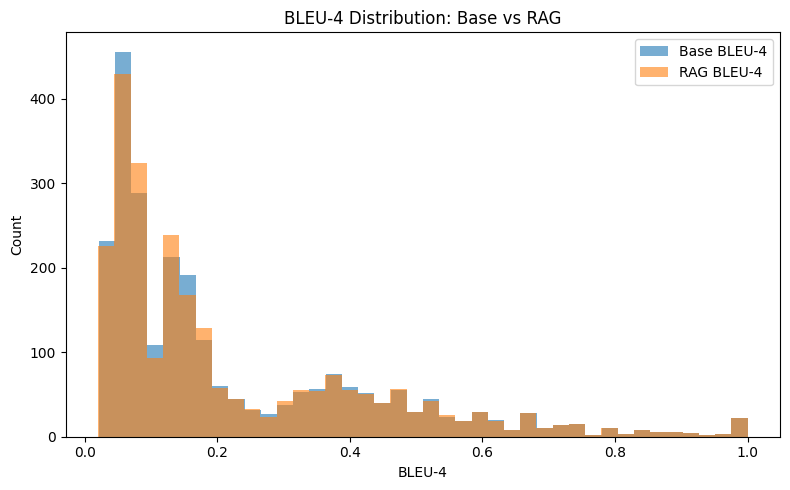

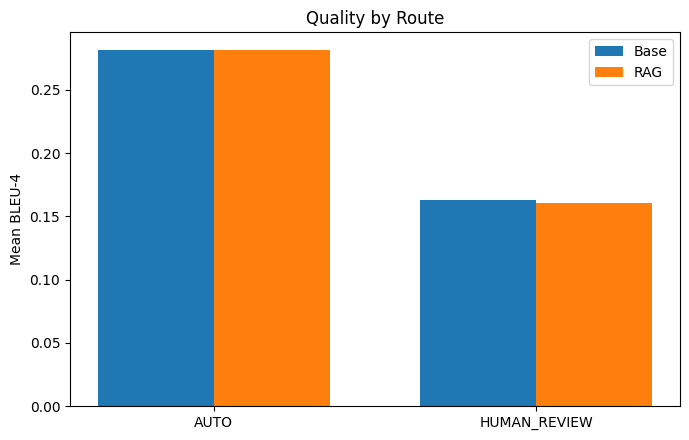

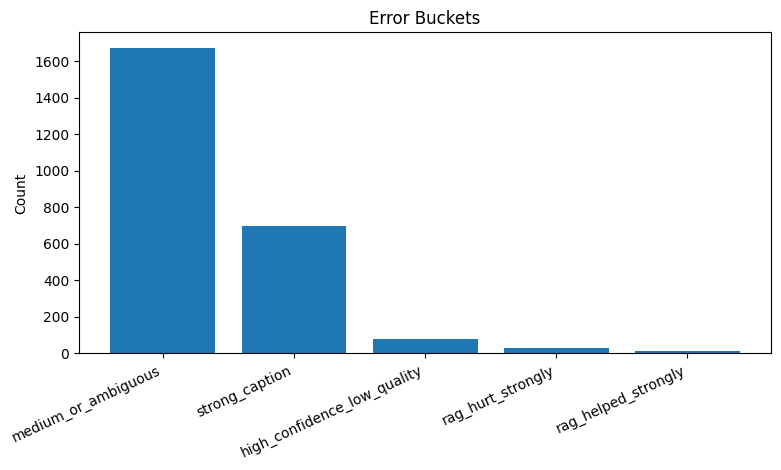

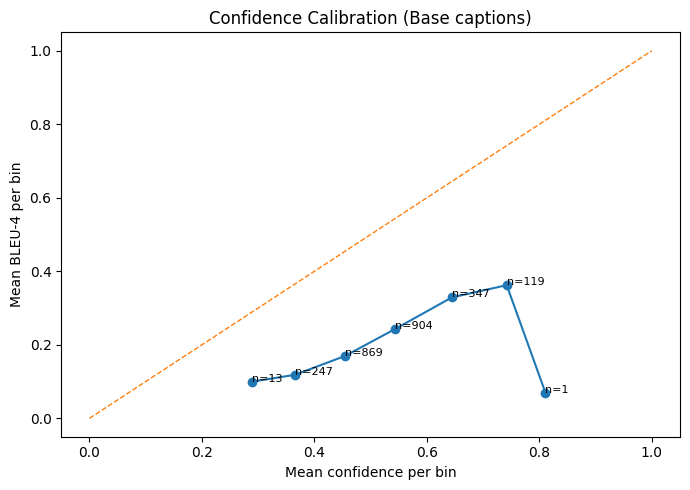

In [6]:
# Cell 6 — Charts
plt.figure(figsize=(8, 5))
auto = df[df["route_policy"] == "AUTO"]
human = df[df["route_policy"] == "HUMAN_REVIEW"]
plt.scatter(auto["confidence"], auto["base_bleu4"], s=14, alpha=0.45, label="AUTO")
plt.scatter(human["confidence"], human["base_bleu4"], s=14, alpha=0.45, label="HUMAN_REVIEW")
plt.axvline(threshold, linestyle="--", linewidth=1.2, label=f"threshold={threshold:.3f}")
plt.xlabel("Confidence")
plt.ylabel("BLEU-4 (base)")
plt.title("Confidence vs BLEU-4")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "chart_confidence_vs_bleu4.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["base_bleu4"].dropna(), bins=40, alpha=0.6, label="Base BLEU-4")
plt.hist(df["rag_bleu4"].dropna(), bins=40, alpha=0.6, label="RAG BLEU-4")
plt.xlabel("BLEU-4")
plt.ylabel("Count")
plt.title("BLEU-4 Distribution: Base vs RAG")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "chart_bleu_hist_base_vs_rag.png", dpi=180)
plt.show()

route_plot = route_summary.copy()
x = np.arange(len(route_plot))
w = 0.36
plt.figure(figsize=(7, 4.5))
plt.bar(x - w/2, route_plot["base_bleu4_mean"], width=w, label="Base")
plt.bar(x + w/2, route_plot["rag_bleu4_mean"], width=w, label="RAG")
plt.xticks(x, route_plot["route_policy"])
plt.ylabel("Mean BLEU-4")
plt.title("Quality by Route")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "chart_route_quality.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 4.8))
plt.bar(bucket_counts["error_bucket"], bucket_counts["count"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Count")
plt.title("Error Buckets")
plt.tight_layout()
plt.savefig(OUT / "chart_error_buckets.png", dpi=180)
plt.show()

# Confidence calibration curve (bin confidence vs mean BLEU)
bins = np.linspace(0, 1, 11)
df["conf_bin"] = pd.cut(df["confidence"], bins=bins, include_lowest=True)
cal = (
    df.groupby("conf_bin", as_index=False)
      .agg(mean_conf=("confidence", "mean"), mean_bleu4=("base_bleu4", "mean"), n=("image_name", "count"))
      .dropna()
)
plt.figure(figsize=(7, 5))
plt.plot(cal["mean_conf"], cal["mean_bleu4"], marker="o")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
for _, r in cal.iterrows():
    plt.text(r["mean_conf"], r["mean_bleu4"], f"n={int(r['n'])}", fontsize=8)
plt.xlabel("Mean confidence per bin")
plt.ylabel("Mean BLEU-4 per bin")
plt.title("Confidence Calibration (Base captions)")
plt.tight_layout()
plt.savefig(OUT / "chart_confidence_calibration.png", dpi=180)
plt.show()


In [7]:
# Cell 7 — Save all analysis artifacts
df.to_csv(OUT / "analysis_master.csv", index=False)
overall.to_csv(OUT / "overall_summary.csv", index=False)
route_summary.to_csv(OUT / "route_summary.csv", index=False)
rag_usage_summary.to_csv(OUT / "rag_usage_summary.csv", index=False)
bucket_counts.to_csv(OUT / "error_bucket_counts.csv", index=False)

top20_best.to_csv(OUT / "top20_best_base_bleu4.csv", index=False)
top20_worst.to_csv(OUT / "top20_worst_base_bleu4.csv", index=False)
top20_rag_improved.to_csv(OUT / "top20_rag_improved.csv", index=False)
top20_rag_degraded.to_csv(OUT / "top20_rag_degraded.csv", index=False)

summary_md = f"""# Error Analysis Summary

## Key numbers
- Images evaluated: {int(overall.loc[0,'n_images'])}
- Policy threshold: {overall.loc[0,'policy_threshold']:.4f}
- Base BLEU-4 mean: {overall.loc[0,'base_bleu4_mean']:.4f}
- RAG BLEU-4 mean: {overall.loc[0,'rag_bleu4_mean']:.4f}
- Mean delta (RAG - Base): {overall.loc[0,'delta_bleu4_mean']:.4f}
- RAG used retrieval rate: {overall.loc[0,'rag_used_rate']:.2%}
- Improvement rate (RAG > Base): {overall.loc[0,'improved_rate_(rag>base)']:.2%}
- Degradation rate (RAG < Base): {overall.loc[0,'degraded_rate_(rag<base)']:.2%}

## Route-level finding
AUTO vs HUMAN_REVIEW quality differences are captured in `route_summary.csv`.

## Notes
This stage is evaluation/testing only (no retraining). Outputs support report and vlog evidence.
"""
(OUT / "error_analysis_summary.md").write_text(summary_md, encoding="utf-8")

print("Saved artifacts to:", OUT)


Saved artifacts to: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/final/error_analysis


In [8]:
# Cell 8 — Gate check
required = [
    OUT / "analysis_master.csv",
    OUT / "overall_summary.csv",
    OUT / "route_summary.csv",
    OUT / "rag_usage_summary.csv",
    OUT / "error_bucket_counts.csv",
    OUT / "top20_best_base_bleu4.csv",
    OUT / "top20_worst_base_bleu4.csv",
    OUT / "top20_rag_improved.csv",
    OUT / "top20_rag_degraded.csv",
    OUT / "chart_confidence_vs_bleu4.png",
    OUT / "chart_bleu_hist_base_vs_rag.png",
    OUT / "chart_route_quality.png",
    OUT / "chart_error_buckets.png",
    OUT / "chart_confidence_calibration.png",
    OUT / "error_analysis_summary.md",
]

for p in required:
    assert p.exists(), f"Missing: {p}"

print("STAGE ERROR ANALYSIS PASS ")
print("Artifacts:", OUT)


STAGE ERROR ANALYSIS PASS 
Artifacts: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/final/error_analysis
